<span style="text-align: center; color:#009999;">

# [LGBIO2050] - Medical Imaging
## *Challenge 1 - Histogram Equalization*
</span>

### Professors :   
- Prof. G. Kerckhofs  
- Prof. J. Lee
- Prof. B. Macq
- Prof. G. Duchêne
    
### Teaching assistants : 
- Pauline Hermans (pauline.hermans@uclouvain.be)
- Nicolas Delinte (nicolas.delinte@uclouvain.be)
- Simon Francois (simon.b.francois@uclouvain.be)

**2026-2027**

<span style="color:#009999;">

## 1. Guidelines and Deliverables
</span>

- This assignment is due on **14th October 2026**.
- The jupyter notebook containing the code and **detailed answers** to the questions must be delivered in an archive (.zip folder) on Moodle, with *"Markdown cells"* containing the answer to the questions and *"Code cells"* containing the code you implemented. The answers have to be written in English.
- This work must comply with the **EPL AI Guidelines** (available on Moodle) concerning the responsible use of AI in student work. Copying code or answers from other groups or from the internet is strictly prohibited. **Any source used for inspiration must be clearly acknowledged and referenced.**
- At the end of the semester, an **individual evaluation** will allow you to demonstrate that you have a good understanding of the challenge, both in terms of the code you have written and the answers to the reflection questions. Make sure that **all group members are familiar with each challenge and understand how it works**.
- The **presentation and overall formatting of your notebook** will also be taken into account in the assessment. Make sure to **write clean, efficient, well-structured code and comment it** appropriately to make it easy to understand. Your outputs and figures should also be clear and well-presented (do not forget titles, legends, etc. where appropriate). Pay particular attention to your answers to the questions as well. **Structure your explanations clearly** and use titles, subtitles, figures, and other relevant elements to make your **answers clear and precise**.  

<span style="color:#009999;">

## 2. Context and objective
</span>

When dealing with in vivo medical image acquisition, it happens that images contain significant amount of details which are not visually perceptible. 
One reason for this may be that these images are poorly contrasted, i.e., they have a poor dynamic range in their 
pixel intensities. In such situation, applying a transformation to the image that will stretch its dynamic range is 
often desirable.<br>


The normalised histogram of a gray level image is defined by the following equation:
 
$$ p(k)=\frac{n_{k}}{N}$$

where $n_{k}$  is the the number of pixels with gray level $k$ and $N$ is the total number of 
pixels. $p(k)$ can be interpreted as the probability of occurrence of gray level $k$. A plot of $n_{k}$ versus $k$ is known as a histogram.

The [cumulative distribution function](https://en.wikipedia.org/wiki/Cumulative_distribution_function) ($cdf$) of grayscale values in an image is then defined as
$$cdf(k)=\sum_{j=0}^{k} p(j)$$
Gray level transformations applied to the histogram are among the simplest of image enhancement techniques. However, such transforms have a wide range of applications despite their simplicity.<br>


Histogram Equalization (HE) is the transformation of the histogram denoted by $T$ :

$$ T(k)= cdf(k) $$


<span style="color:#009999;">

## 3. Data import
</span>

In this challenge, you will learn how to easily adjust the contrast of a medical image in order to reveal unvisible detailed. For this challenge, we will use three images, a **X-ray radiography** of a chest and another one of the knee (this modality is detailed in part 3.1 of the course), and a **CT image** of a skull. X-rays radiography uses electromagnetic radiation that can penetrate the body to varying degrees depending on the density of the tissues they encounter. It is commonly used to observe bones (e.g., fractures) and the thoracic area (e.g. pneumonia) as this modality provides a good contrast for hard tissues and for the air-filled lung spaces.

<div class="alert alert-info">

**QUESTION 1**

In the following cell, import and display the images: the chest and knee radiographs and the skull image (chest.png, knee.jpeg & skull.png).  

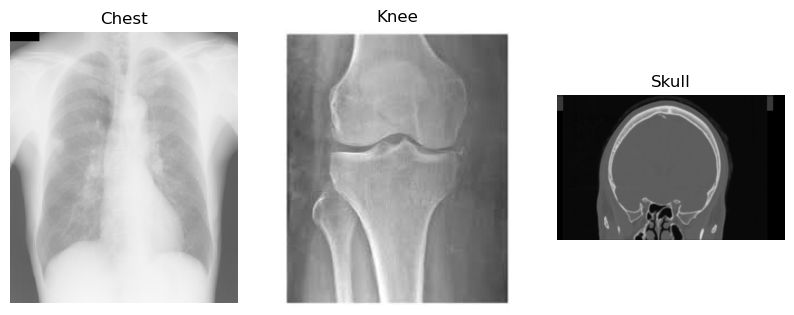

In [2]:
from skimage.io import imread
from skimage.color import rgb2gray
import numpy as np
import matplotlib.pyplot as plt

#Read the images
im1 = imread("chest.png")
im2 = imread("knee.jpeg")
im3 = imread("skull.png")

#Plot the images
fig, ax = plt.subplots(1,3,figsize=(10,8))
ax[0].imshow(im1)
ax[0].set_title('Chest')
ax[0].axis("off")
ax[1].imshow(im2)
ax[1].set_title('Knee')
ax[1].axis("off")
ax[2].imshow(im3)
ax[2].set_title('Skull')
ax[2].axis("off")

plt.show()

<span style="color:#009999;">

## 4. Histogram Equalization implementation
</span>

<div class="alert alert-info">

**QUESTION 2**

Implement, by yourself, the Histogram Equalization method. 

You are not allowed to use implemented version of the code (openCV, Skimage, PIL,...). The implementation can be achieved using only Numpy. Show your results on all three images, as well as their histograms and cumulative distribution functions (*cdf*), and comment them.

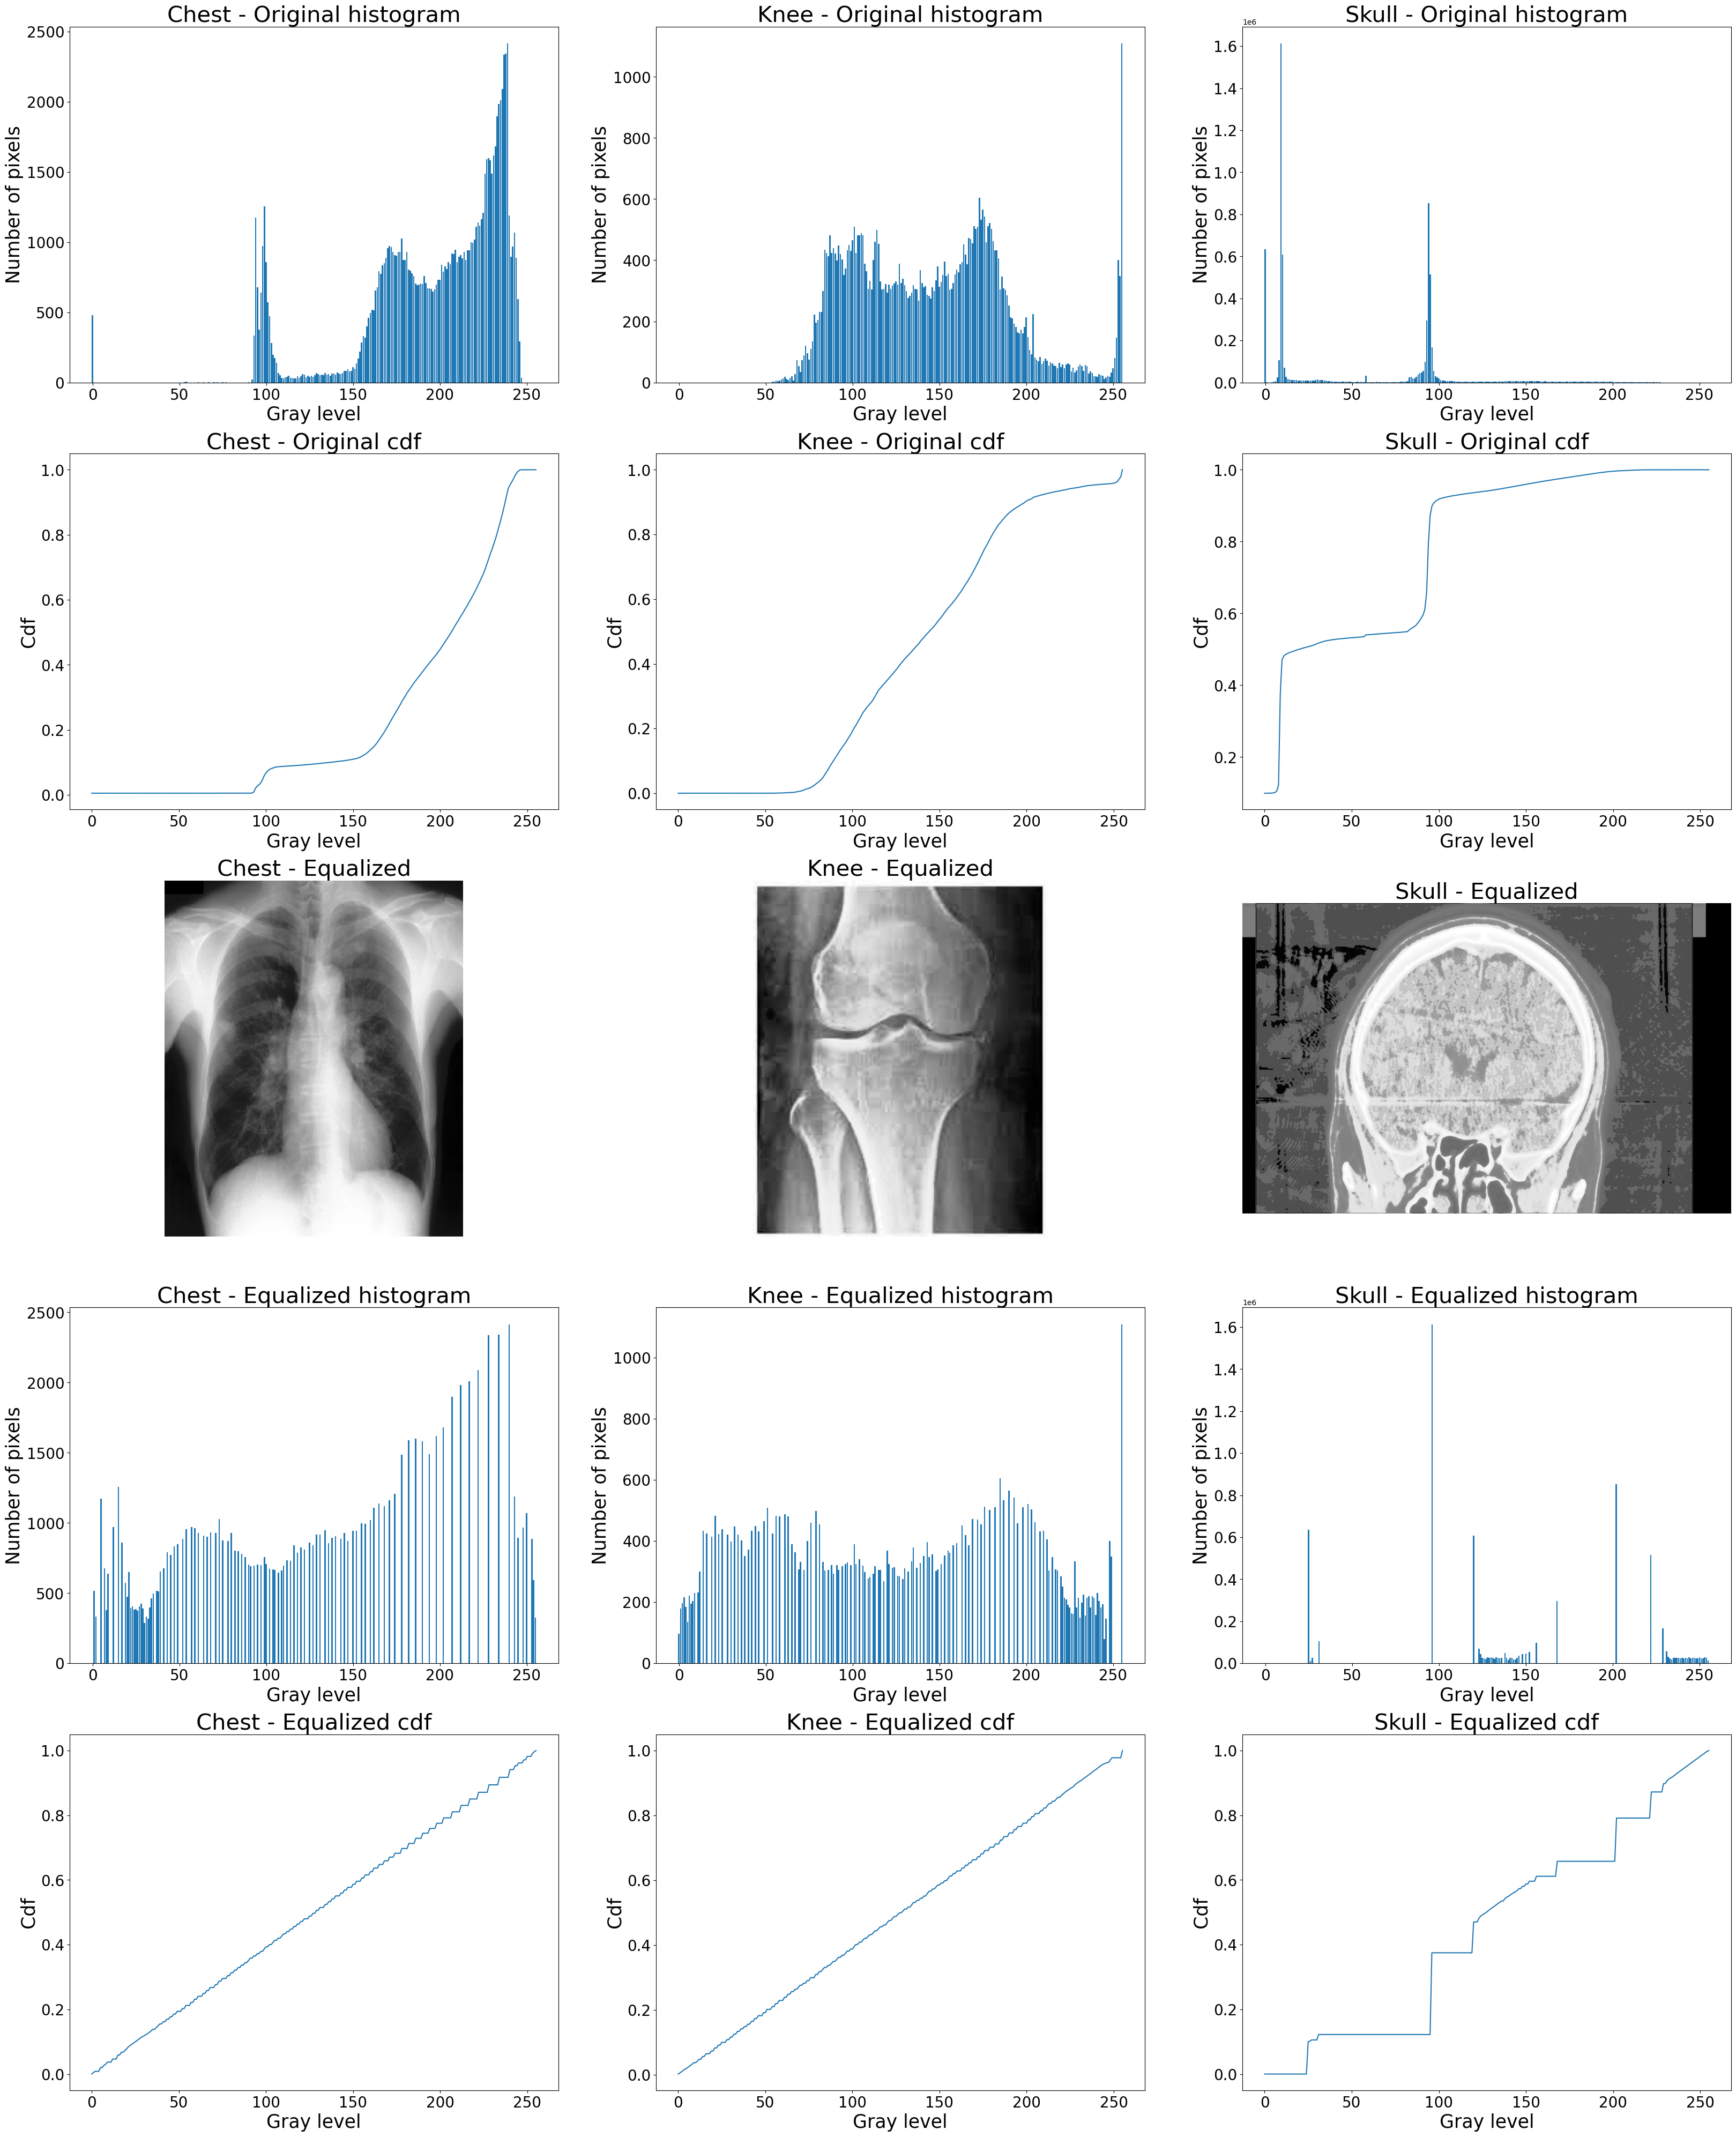

In [3]:
# Histogram Equalization implementation
from skimage.color import rgba2rgb

def histeq(im):
    
    #Put the images from RGB/RGBA to gray
    if len(im.shape) == 3 and im.shape[2] == 3 :
        gray_im = rgb2gray(im)
    elif len(im.shape) == 3 and im.shape[2] == 4 :
        gray_im = rgba2rgb(im)
        gray_im = rgb2gray(gray_im)
    else : 
        gray_im = im
        
    #Rescale the images if necessary and put them in uint8    
    if gray_im.max()<=1.0 :
        gray_im = np.round(255*gray_im).astype(np.uint8)
    else :
        gray_im = gray_im.astype(np.uint8)
    
    #Do the histogram equalization 
    N = gray_im.size
    counts, bins = np.histogram(gray_im.ravel(), bins=256, range=(0,256))
    p_k = counts/N
    cdf_k = np.cumsum(p_k)
    T_k = np.round(255*cdf_k).astype(np.uint8)
    im_eq = T_k[gray_im]
    counts_eq, bins_eq = np.histogram(im_eq.ravel(), bins=256, range=(0,256))
    p_eq = counts_eq/N
    cdf_eq = np.cumsum(p_eq)
    
    return im_eq, counts, bins, counts_eq, bins_eq, cdf_k, cdf_eq, T_k

#Call the variables
im_eq1, counts1, bins1, counts_eq1, bins_eq1, cdf_k1, cdf_eq1, T_k1 = histeq(im1)
im_eq2, counts2, bins2, counts_eq2, bins_eq2, cdf_k2, cdf_eq2, T_k2 = histeq(im2)
im_eq3, counts3, bins3, counts_eq3, bins_eq3, cdf_k3, cdf_eq3, T_k3 = histeq(im3)

#Plot the results
fig, ax = plt.subplots(5,3,figsize=(40,50))
ax[0,0].bar(bins1[:-1], counts1)
ax[0,0].set_title('Chest - Original histogram', fontsize=30)
ax[0,0].set_xlabel('Gray level', fontsize=25)
ax[0,0].set_ylabel('Number of pixels', fontsize=25)
ax[0,0].tick_params(axis='both', labelsize=20)
ax[0,1].bar(bins2[:-1], counts2)
ax[0,1].set_title('Knee - Original histogram', fontsize=30)
ax[0,1].set_xlabel('Gray level', fontsize=25)
ax[0,1].set_ylabel('Number of pixels', fontsize=25)
ax[0,1].tick_params(axis='both', labelsize=20)
ax[0,2].bar(bins3[:-1], counts3)
ax[0,2].set_title('Skull - Original histogram', fontsize=30)
ax[0,2].set_xlabel('Gray level', fontsize=25)
ax[0,2].set_ylabel('Number of pixels', fontsize=25)
ax[0,2].tick_params(axis='both', labelsize=20)

ax[1,0].plot(bins1[:-1], cdf_k1)
ax[1,0].set_title('Chest - Original cdf', fontsize=30)
ax[1,0].set_xlabel('Gray level', fontsize=25)
ax[1,0].set_ylabel('Cdf', fontsize=25)
ax[1,0].tick_params(axis='both', labelsize=20)
ax[1,1].plot(bins2[:-1], cdf_k2)
ax[1,1].set_title('Knee - Original cdf', fontsize=30)
ax[1,1].set_xlabel('Gray level', fontsize=25)
ax[1,1].set_ylabel('Cdf', fontsize=25)
ax[1,1].tick_params(axis='both', labelsize=20)
ax[1,2].plot(bins3[:-1], cdf_k3)
ax[1,2].set_title('Skull - Original cdf', fontsize=30)
ax[1,2].set_xlabel('Gray level', fontsize=25)
ax[1,2].set_ylabel('Cdf', fontsize=25)
ax[1,2].tick_params(axis='both', labelsize=20)

ax[2,0].imshow(im_eq1, cmap='gray')
ax[2,0].set_title('Chest - Equalized', fontsize=30)
ax[2,0].axis("off")
ax[2,1].imshow(im_eq2, cmap='gray')
ax[2,1].set_title('Knee - Equalized', fontsize=30)
ax[2,1].axis("off")
ax[2,2].imshow(im_eq3, cmap='gray')
ax[2,2].set_title('Skull - Equalized', fontsize=30)
ax[2,2].axis("off")

ax[3,0].bar(bins_eq1[:-1], counts_eq1)
ax[3,0].set_title('Chest - Equalized histogram', fontsize=30)
ax[3,0].set_xlabel('Gray level', fontsize=25)
ax[3,0].set_ylabel('Number of pixels', fontsize=25)
ax[3,0].tick_params(axis='both', labelsize=20)
ax[3,1].bar(bins_eq2[:-1], counts_eq2)
ax[3,1].set_title('Knee - Equalized histogram', fontsize=30)
ax[3,1].set_xlabel('Gray level', fontsize=25)
ax[3,1].set_ylabel('Number of pixels', fontsize=25)
ax[3,1].tick_params(axis='both', labelsize=20)
ax[3,2].bar(bins_eq3[:-1], counts_eq3)
ax[3,2].set_title('Skull - Equalized histogram', fontsize=30)
ax[3,2].set_xlabel('Gray level', fontsize=25)
ax[3,2].set_ylabel('Number of pixels', fontsize=25)
ax[3,2].tick_params(axis='both', labelsize=20)

ax[4,0].plot(bins_eq1[:-1], cdf_eq1)
ax[4,0].set_title('Chest - Equalized cdf', fontsize=30)
ax[4,0].set_xlabel('Gray level', fontsize=25)
ax[4,0].set_ylabel('Cdf', fontsize=25)
ax[4,0].tick_params(axis='both', labelsize=20)
ax[4,1].plot(bins_eq2[:-1], cdf_eq2)
ax[4,1].set_title('Knee - Equalized cdf', fontsize=30)
ax[4,1].set_xlabel('Gray level', fontsize=25)
ax[4,1].set_ylabel('Cdf', fontsize=25)
ax[4,1].tick_params(axis='both', labelsize=20)
ax[4,2].plot(bins_eq3[:-1], cdf_eq3)
ax[4,2].set_title('Skull - Equalized cdf', fontsize=30)
ax[4,2].set_xlabel('Gray level', fontsize=25)
ax[4,2].set_ylabel('Cdf', fontsize=25)
ax[4,2].tick_params(axis='both', labelsize=20)

plt.show()
        

**2.A. - Comments on the results on the chest radiographs and associated histogram:**

# Results on the chest (image, histogram and *cdf*)
With the histogram equalization, the radiography of the chest is more contrasted. 
The gray levels are redistributed across the whole dynamic range (0 to 255). 
We can clearly see the different anatomical structures such as the ribbing. 

For the histogram, we see that the pixels were more grouped together at some gray levels but after 
the histogram equalization, we see that the pixels are much more separated in the whole range.

For the cdf, we see again that the pixels were more grouped together at some gray levels so the function 
increased at some specific gray levels. After the histogram equalization, we see that the cdf is close to be linear
because the pixels are separated in the whole range.

**2.B. Comments on the results on the knee radiographs and associated histogram:**

# Results on the knee (image, histogram and *cdf*)
With the equalization, the radiography of the knee is also more contrasted. 
The gray levels are redistributed across the whole dynamic range (0 to 255). 
We can clearly see the different anatomical structures such as the bones.

For the histogram, we see that the pixels were more grouped together at some gray levels but after 
the histogram equalization, we see that the pixels are much more separated in the whole range.

For the cdf, we see again that the pixels were more grouped together at some gray levels so the function 
increased at some specific gray levels. After the histogram equalization, we see that the cdf is close to be linear
because the pixels are separated in the whole range.

**2.C. Comments on the results on the CT image and associated histogram:**

# Results on the skull (image, histogram and *cdf*)
With the equalization, the CT image of the knee is also more contrasted. 
The gray levels are redistributed across the whole dynamic range (0 to 255). 
We can clearly see the different anatomical structures such as the brain.

For the histogram, we see that the pixels were more grouped together at some gray levels in some distinct peaks
representing the different types of tissues or other. 
After the histogram equalization, we see that the pixels are forced to be more separated in the range but still in 
some peaks that have no real sense anymore. 

For the cdf, we see again that the pixels were more grouped together at some gray levels dependaing on the tissus
so the function increased at some specific gray levels. After the histogram equalization, we see that the cdf is 
forced to be more linear so we do not see the stairs depending on the tissues types anymore.

<div class="alert alert-info">
    
**QUESTION 3**

What are the main drawbacks of Histogram Equalization? Do you see these drawbacks on the three images?

The Histogram Equalization amplifies the noise as we can see in the knee.
Another thing is that with this equalization, we lose some important details sometimes, due to the regrouping of close gray levels, as we can see in the chest with less contrast at some places.
Another drawback is that for CT images like the skull here, it destroys the clear separation between the tissus types. And we can also see the marks from the beam.

<div class="alert alert-info">
    
**QUESTION 4**

What happens when you apply consecutively Histogram Equalization multiple times on the same image?

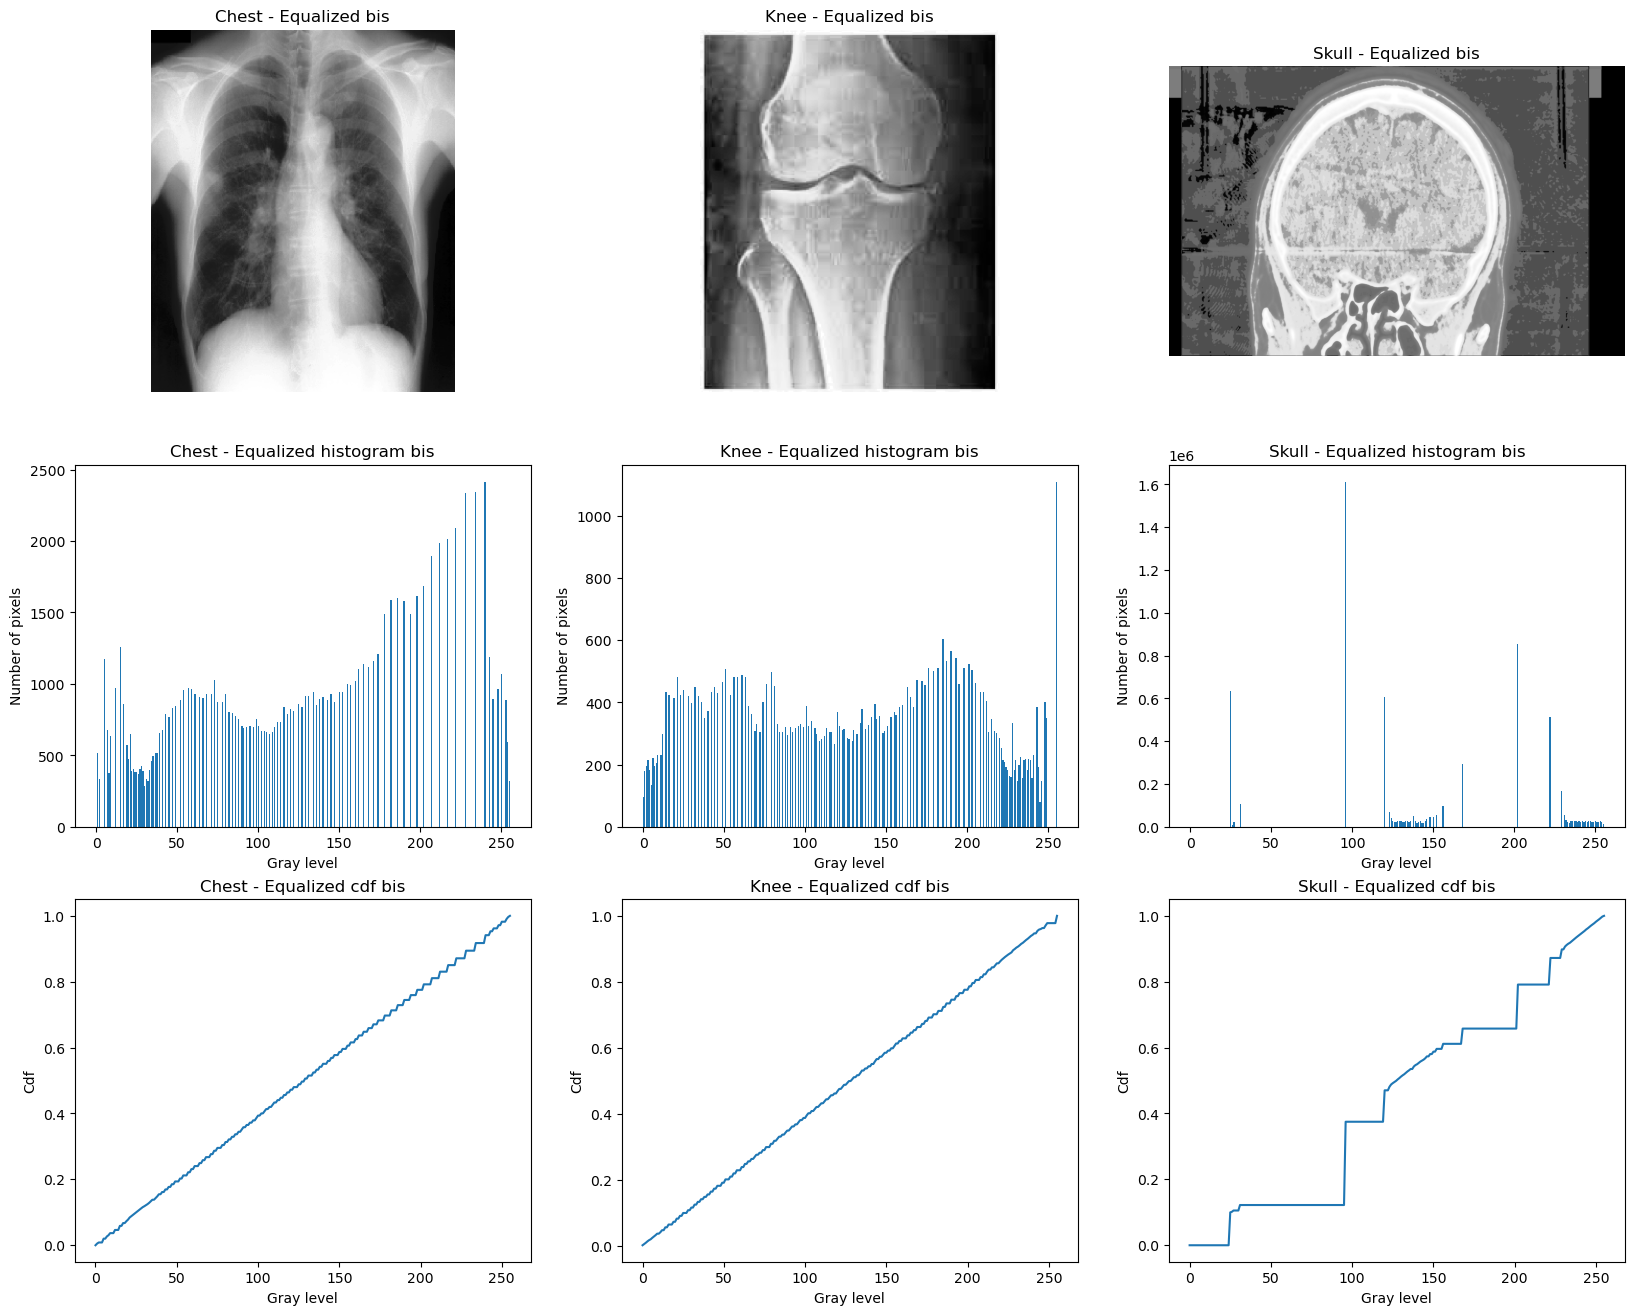

In [4]:
# Show the results here

#Call the variables
im_eq11, counts11, bins11, counts_eq11, bins_eq11, cdf_k11, cdf_eq11, T_k11 = histeq(im_eq1)
im_eq22, counts22, bins22, counts_eq22, bins_eq22, cdf_k22, cdf_eq22, T_k22 = histeq(im_eq2)
im_eq33, counts33, bins33, counts_eq33, bins_eq33, cdf_k33, cdf_eq33, T_k33 = histeq(im_eq3)

#Plot the results
fig, ax = plt.subplots(3,3,figsize=(20,16))

ax[0,0].imshow(im_eq11, cmap='gray')
ax[0,0].set_title('Chest - Equalized bis')
ax[0,0].axis("off")
ax[0,1].imshow(im_eq22, cmap='gray')
ax[0,1].set_title('Knee - Equalized bis')
ax[0,1].axis("off")
ax[0,2].imshow(im_eq33, cmap='gray')
ax[0,2].set_title('Skull - Equalized bis')
ax[0,2].axis("off")

ax[1,0].bar(bins_eq11[:-1], counts_eq11)
ax[1,0].set_title('Chest - Equalized histogram bis')
ax[1,0].set_xlabel('Gray level')
ax[1,0].set_ylabel('Number of pixels')
ax[1,1].bar(bins_eq22[:-1], counts_eq22)
ax[1,1].set_title('Knee - Equalized histogram bis')
ax[1,1].set_xlabel('Gray level')
ax[1,1].set_ylabel('Number of pixels')
ax[1,2].bar(bins_eq33[:-1], counts_eq33)
ax[1,2].set_title('Skull - Equalized histogram bis')
ax[1,2].set_xlabel('Gray level')
ax[1,2].set_ylabel('Number of pixels')

ax[2,0].plot(bins_eq11[:-1], cdf_eq11)
ax[2,0].set_title('Chest - Equalized cdf bis')
ax[2,0].set_xlabel('Gray level')
ax[2,0].set_ylabel('Cdf')
ax[2,1].plot(bins_eq22[:-1], cdf_eq22)
ax[2,1].set_title('Knee - Equalized cdf bis')
ax[2,1].set_xlabel('Gray level')
ax[2,1].set_ylabel('Cdf')
ax[2,2].plot(bins_eq33[:-1], cdf_eq33)
ax[2,2].set_title('Skull - Equalized cdf bis')
ax[2,2].set_xlabel('Gray level')
ax[2,2].set_ylabel('Cdf')

plt.show()

**Comments on the multiple times application:**

That does not change anything. We can do it one time or multiple times, that gives the same results. It is because when we do an histogram equalization, the histogram is distributed the first time with the cdf and then when we re-do it the histogram will not change anymore.

<div class="alert alert-info">
    
**QUESTION 5**

What happens when the number of bins in the histogram used to compute the equalization is reduced?

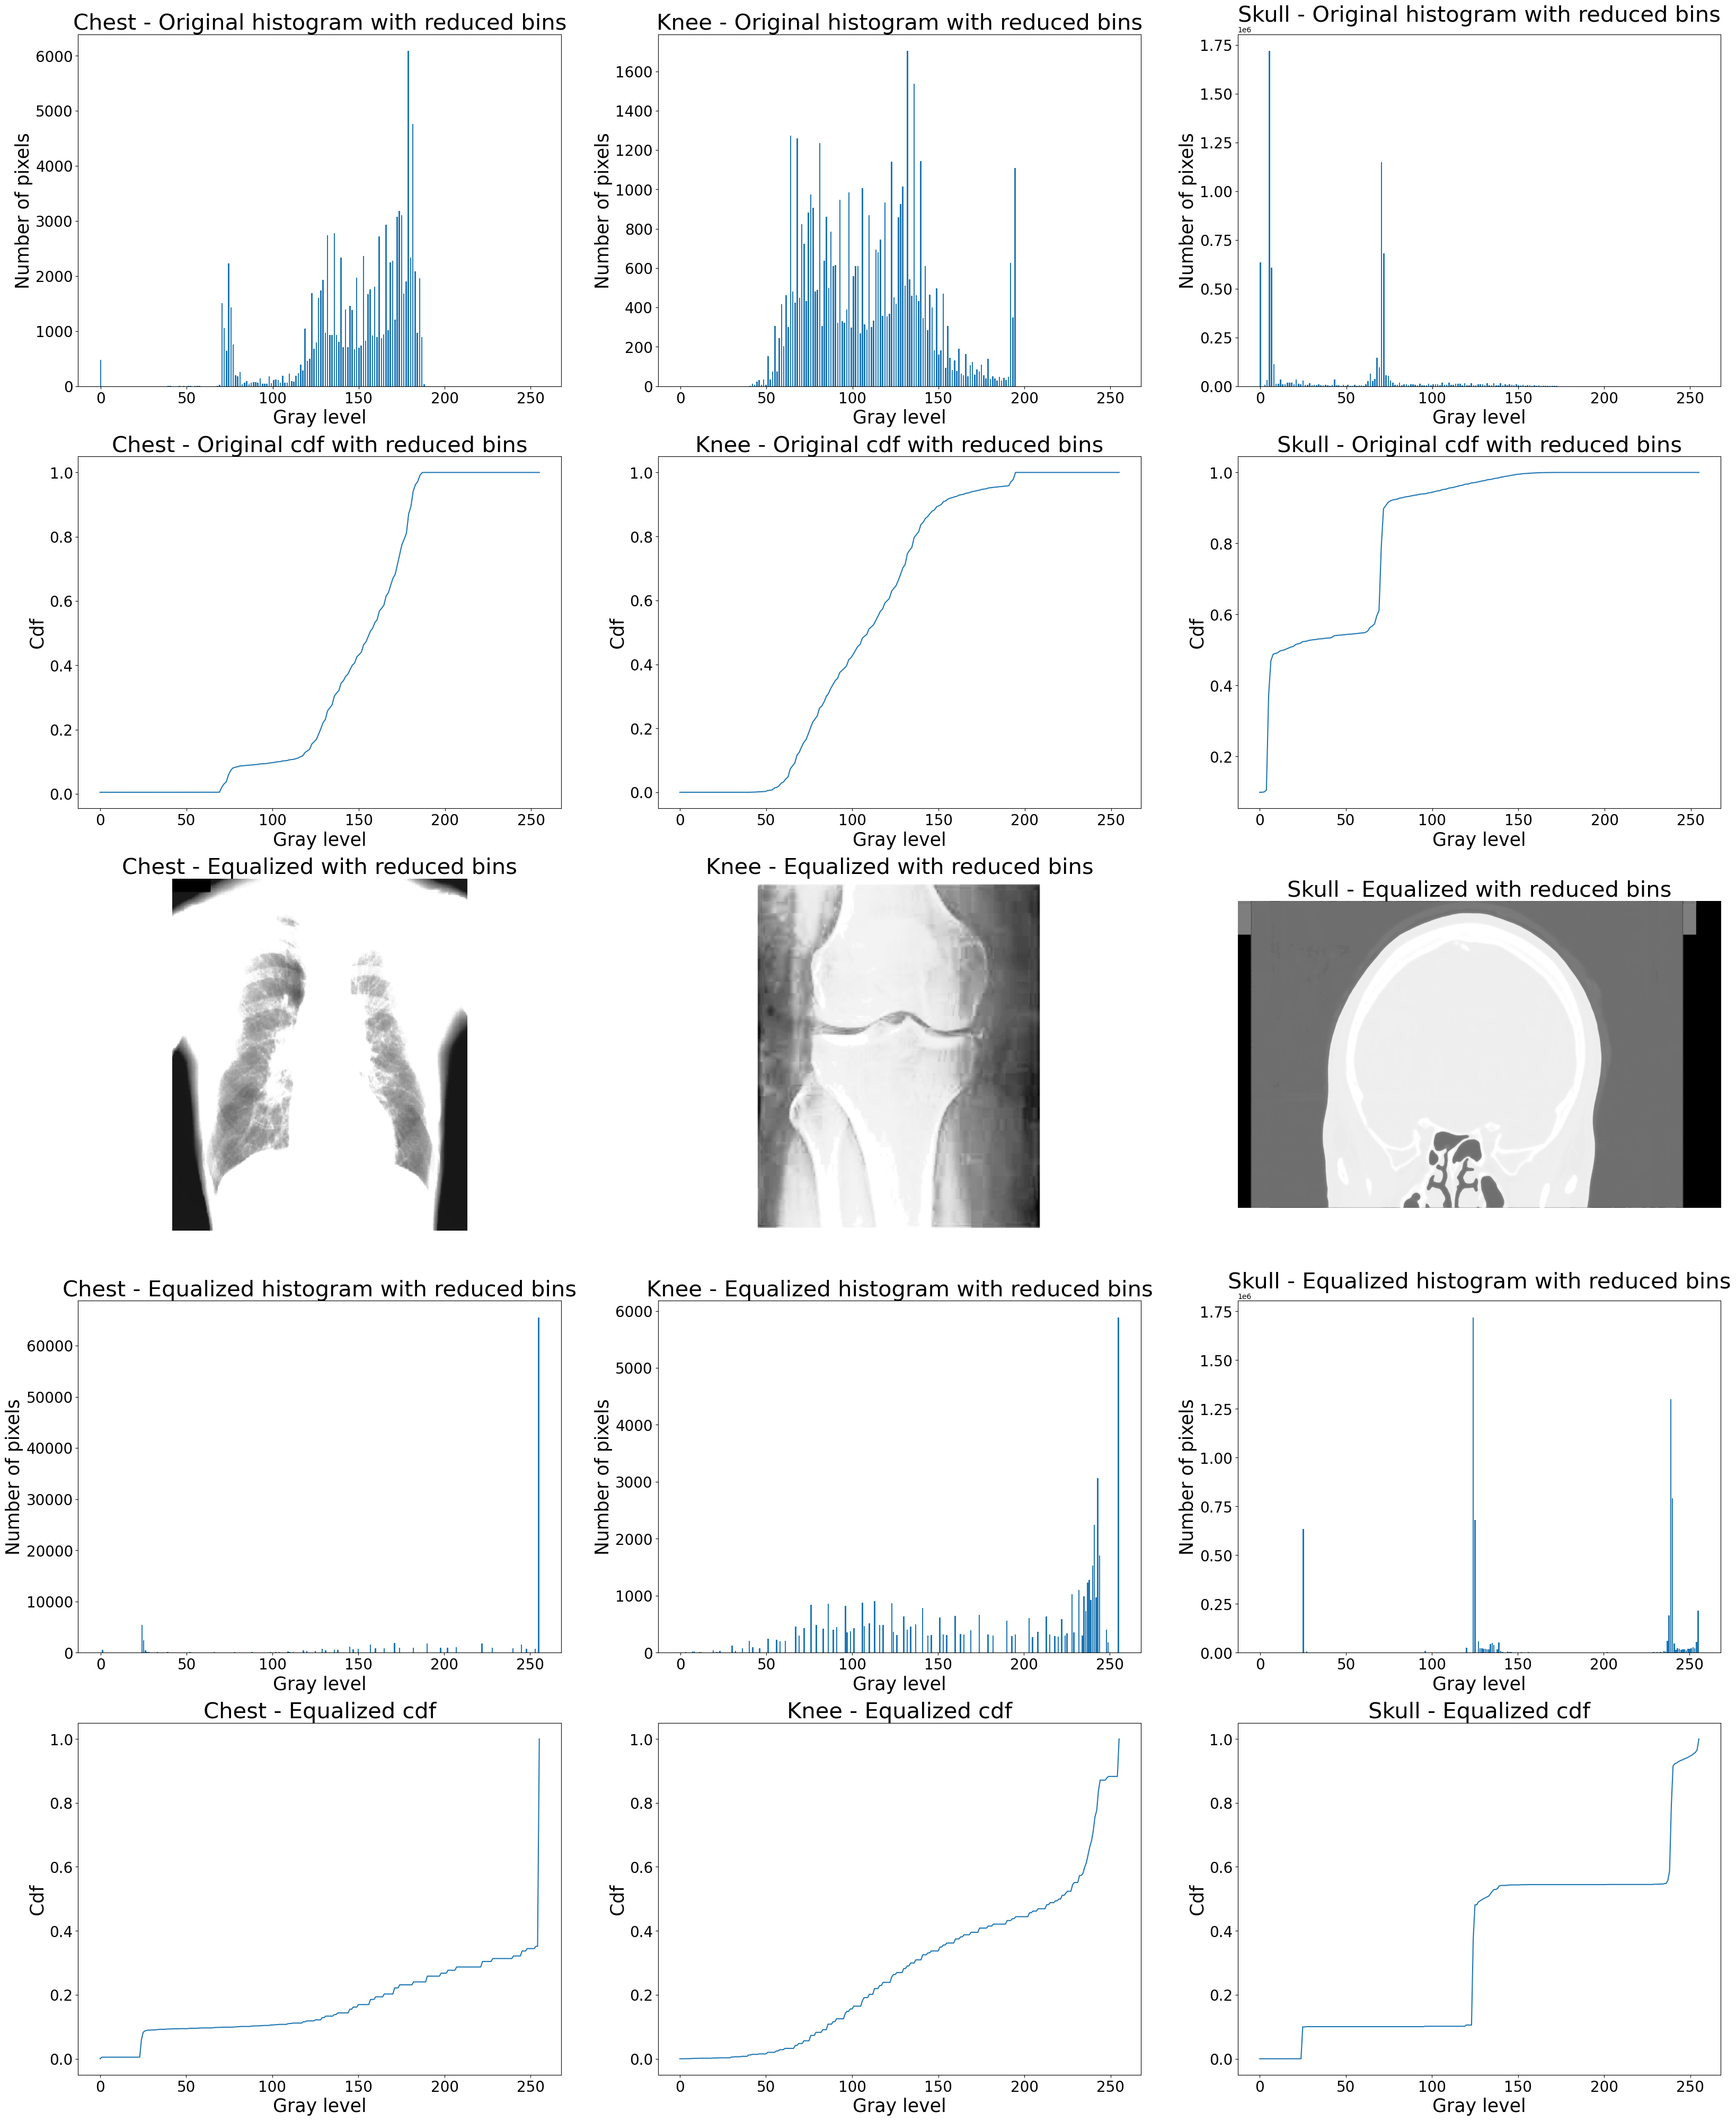

In [8]:
# Show the results here
def histeq_reduced_bins(im, reduced_bins):
    
    #Put the images from RGB/RGBA to gray
    if len(im.shape) == 3 and im.shape[2] == 3 :
        gray_im = rgb2gray(im)
    elif len(im.shape) == 3 and im.shape[2] == 4 :
        gray_im = rgba2rgb(im)
        gray_im = rgb2gray(gray_im)
    else : 
        gray_im = im
    
    #Rescale the images if necessary and put them in uint8
    if gray_im.max()<=1.0 :
        gray_im = np.round(255*gray_im).astype(np.uint8)
    else :
        gray_im = gray_im.astype(np.uint8)
    
    #Do the histogram equalization with reduced bins
    N = gray_im.size
    bin_size = 256/reduced_bins
    reduced_bins_im = (gray_im/bin_size).astype(np.uint8)
    counts, bins = np.histogram(reduced_bins_im.ravel(), bins=reduced_bins, range=(0,256))
    p_k = counts/N
    cdf_k = np.cumsum(p_k)
    T_k = np.round(255*cdf_k).astype(np.uint8)
    im_eq = T_k[reduced_bins_im]
    counts_eq, bins_eq = np.histogram(im_eq.ravel(), bins=256, range=(0,256))
    p_eq = counts_eq/N
    cdf_eq = np.cumsum(p_eq)
    
    return im_eq, counts, bins, counts_eq, bins_eq, cdf_k, cdf_eq, T_k

#Call the variables for 196 bins
im_eq1, counts1, bins1, counts_eq1, bins_eq1, cdf_k1, cdf_eq1, T_k1 = histeq_reduced_bins(im1,196)
im_eq2, counts2, bins2, counts_eq2, bins_eq2, cdf_k2, cdf_eq2, T_k2 = histeq_reduced_bins(im2,196)
im_eq3, counts3, bins3, counts_eq3, bins_eq3, cdf_k3, cdf_eq3, T_k3 = histeq_reduced_bins(im3,196)

#Plot the results
fig, ax = plt.subplots(5,3,figsize=(40,50))
ax[0,0].bar(bins1[:-1], counts1)
ax[0,0].set_title('Chest - Original histogram with reduced bins', fontsize=30)
ax[0,0].set_xlabel('Gray level', fontsize=25)
ax[0,0].set_ylabel('Number of pixels', fontsize=25)
ax[0,0].tick_params(axis='both', labelsize=20)
ax[0,1].bar(bins2[:-1], counts2)
ax[0,1].set_title('Knee - Original histogram with reduced bins', fontsize=30)
ax[0,1].set_xlabel('Gray level', fontsize=25)
ax[0,1].set_ylabel('Number of pixels', fontsize=25)
ax[0,1].tick_params(axis='both', labelsize=20)
ax[0,2].bar(bins3[:-1], counts3)
ax[0,2].set_title('Skull - Original histogram with reduced bins', fontsize=30)
ax[0,2].set_xlabel('Gray level', fontsize=25)
ax[0,2].set_ylabel('Number of pixels', fontsize=25)
ax[0,2].tick_params(axis='both', labelsize=20)

ax[1,0].plot(bins1[:-1], cdf_k1)
ax[1,0].set_title('Chest - Original cdf with reduced bins', fontsize=30)
ax[1,0].set_xlabel('Gray level', fontsize=25)
ax[1,0].set_ylabel('Cdf', fontsize=25)
ax[1,0].tick_params(axis='both', labelsize=20)
ax[1,1].plot(bins2[:-1], cdf_k2)
ax[1,1].set_title('Knee - Original cdf with reduced bins', fontsize=30)
ax[1,1].set_xlabel('Gray level', fontsize=25)
ax[1,1].set_ylabel('Cdf', fontsize=25)
ax[1,1].tick_params(axis='both', labelsize=20)
ax[1,2].plot(bins3[:-1], cdf_k3)
ax[1,2].set_title('Skull - Original cdf with reduced bins', fontsize=30)
ax[1,2].set_xlabel('Gray level', fontsize=25)
ax[1,2].set_ylabel('Cdf', fontsize=25)
ax[1,2].tick_params(axis='both', labelsize=20)

ax[2,0].imshow(im_eq1, cmap='gray')
ax[2,0].set_title('Chest - Equalized with reduced bins', fontsize=30)
ax[2,0].axis("off")
ax[2,1].imshow(im_eq2, cmap='gray')
ax[2,1].set_title('Knee - Equalized with reduced bins', fontsize=30)
ax[2,1].axis("off")
ax[2,2].imshow(im_eq3, cmap='gray')
ax[2,2].set_title('Skull - Equalized with reduced bins', fontsize=30)
ax[2,2].axis("off")

ax[3,0].bar(bins_eq1[:-1], counts_eq1)
ax[3,0].set_title('Chest - Equalized histogram with reduced bins', fontsize=30)
ax[3,0].set_xlabel('Gray level', fontsize=25)
ax[3,0].set_ylabel('Number of pixels', fontsize=25)
ax[3,0].tick_params(axis='both', labelsize=20)
ax[3,1].bar(bins_eq2[:-1], counts_eq2)
ax[3,1].set_title('Knee - Equalized histogram with reduced bins', fontsize=30)
ax[3,1].set_xlabel('Gray level', fontsize=25)
ax[3,1].set_ylabel('Number of pixels', fontsize=25)
ax[3,1].tick_params(axis='both', labelsize=20)
ax[3,2].bar(bins_eq3[:-1], counts_eq3)
ax[3,2].set_title('Skull - Equalized histogram with reduced bins', fontsize=30)
ax[3,2].set_xlabel('Gray level', fontsize=25)
ax[3,2].set_ylabel('Number of pixels', fontsize=25)
ax[3,2].tick_params(axis='both', labelsize=20)

ax[4,0].plot(bins_eq1[:-1], cdf_eq1)
ax[4,0].set_title('Chest - Equalized cdf', fontsize=30)
ax[4,0].set_xlabel('Gray level', fontsize=25)
ax[4,0].set_ylabel('Cdf', fontsize=25)
ax[4,0].tick_params(axis='both', labelsize=20)
ax[4,1].plot(bins_eq2[:-1], cdf_eq2)
ax[4,1].set_title('Knee - Equalized cdf', fontsize=30)
ax[4,1].set_xlabel('Gray level', fontsize=25)
ax[4,1].set_ylabel('Cdf', fontsize=25)
ax[4,1].tick_params(axis='both', labelsize=20)
ax[4,2].plot(bins_eq3[:-1], cdf_eq3)
ax[4,2].set_title('Skull - Equalized cdf', fontsize=30)
ax[4,2].set_xlabel('Gray level', fontsize=25)
ax[4,2].set_ylabel('Cdf', fontsize=25)
ax[4,2].tick_params(axis='both', labelsize=20)

plt.show()

**Comments on the reduced bin number:**

We see less contrast on the image and a lot of pixels that are at 255 (blank). There are clusters of pixels that are forced to the same value since we do not have 256 bins to compute the equalization.